In [1]:
using DelimitedFiles
using PeriodicOrbitTTV

using JLD2

using PyPlot
using LaTeXStrings
using Distributions, LinearAlgebra, StatsBase

using LsqFit
using NbodyGradient

In [2]:
# Based on Rowe+2015
tt_data_full = readdlm("apjs509897t2_mrt.txt")
tt_data_02 = tt_data_full[tt_data_full[:,1] .== "KOI-244.01",:]
tt_data_01 = tt_data_full[tt_data_full[:,1] .== "KOI-244.02",:]

tt_data_01[:,1] .= 1
tt_data_02[:,1] .= 2

tt_data_01[:,3] .= tt_data_01[:,3] .+ tt_data_01[:,4]
tt_data_02[:,3] .= tt_data_02[:,3] .+ tt_data_02[:,4]

# tt_data = convert(Matrix{Float64}, vcat(tt_data_01, tt_data_02)[sample(1:309, 180, replace=false, ordered=true),[1,2,3,5]])
tt_data = convert(Matrix{Float64}, vcat(tt_data_01, tt_data_02)[:,[1,2,3,5]])

309×4 Matrix{Float64}:
 1.0    1.0    54.8074  0.0025274
 1.0    2.0    61.04    0.0024188
 1.0    3.0    67.2743  0.0025465
 1.0    4.0    73.516   0.0027512
 1.0    5.0    79.7535  0.0035079
 1.0    7.0    92.226   0.0020365
 1.0    9.0   104.707   0.0022809
 1.0   10.0   110.94    0.001944
 1.0   11.0   117.183   0.001733
 1.0   12.0   123.415   0.0026881
 1.0   13.0   129.659   0.0020234
 1.0   14.0   135.897   0.0022208
 1.0   16.0   148.374   0.0028006
 ⋮                      
 2.0  104.0  1383.56    0.0007365
 2.0  105.0  1396.28    0.0011252
 2.0  106.0  1409.01    0.0006399
 2.0  107.0  1421.73    0.0012293
 2.0  108.0  1434.45    0.0006426
 2.0  109.0  1447.17    0.0007333
 2.0  110.0  1459.89    0.0007245
 2.0  111.0  1472.61    0.0012425
 2.0  112.0  1485.33    0.0005624
 2.0  113.0  1498.05    0.0005105
 2.0  114.0  1510.77    0.0009454
 2.0  115.0  1523.49    0.0007202

In [3]:
# Code roughly based on the parallel script

function to_matrix(tt::Matrix{T}; err=0.) where T <: Real
    tt_mat = Matrix{T}(undef, 0, 4)
    
    for i in 1:size(tt, 1), j in 1:size(tt, 2)
        if tt[i,j] != 0.0
            tt_mat = vcat(tt_mat, [i-1, j-1, tt[i,j], err]')
        end
    end

    errors = rand(Normal(0., err), size(tt_mat, 1))
    tt_mat[:,3] .= tt_mat[:,3] + errors
    
    return tt_mat
end

using PeriodicOrbitTTV: compute_diff_squared_jacobian, compute_diff_squared

function find_first_transit(nplanet::Int, data::Matrix{T}) where T <: Real
    row_index = [findfirst(isequal(i), data[:,1]) for i = 1:nplanet] 

    return data[row_index, 3]
end

function find_last_transit(nplanet::Int, data::Matrix{T}) where T <: Real
    row_index = [findlast(isequal(i), data[:,1]) for i = 1:nplanet] 

    return data[row_index, 3]
end

function residues(optvec::Vector{T}, truthvec::Vector{T}, weights_periodic::Vector{T}, nplanet::Int, orbparams::OrbitParameters{T}, tt_data::Matrix{T}, scaler::Vector{T}) where T <: Real
    residues = zeros(T, 9nplanet - 1 + size(tt_data, 1))
    optvec = optvec .* scaler
    
    # PO Contribution
    orbit = Orbit(nplanet, OptimParameters(nplanet, optvec), orbparams)
    residues[1:4nplanet-2] = (param_diff(nplanet, orbit.final_elem, orbit.init_elem)[1:end-2]) ./ scaler[1:4nplanet-2]

    # Prior contribution
    residues[4nplanet-1:9nplanet-1] .= 0
    
    # TT Contribution
    tt = compute_tt(orbit, orbparams.obstmax)
    tmod, ip, jp = match_transits(tt_data, orbit, tt.tt, tt.count, nothing)
    # tt_mat = to_matrix(tt.tt)
    residues[9nplanet:end] = tmod
    
    return residues
end

# Read

# clean_params = vec(readdlm("sample_orbit_v1.in"))

nplanet = 2
orbparams = OrbitParameters(2, [0.], 1540.)
# optparams = OptimParameters(2, clean_params)

# orbit_0 = Orbit(2, optparams, orbparams)
# tt = compute_tt(orbit_0, orbparams.obstmax);

function setup_initial_params(tt_data, omegas_0)
    first_transits = find_first_transit(2, tt_data)
    omegas = [omegas_0, omegas_0 + pi]
    init_e = [0.0001, 0.0001]
    omega_diffs = [omegas[i] - omegas[i-1] for i = 2:length(omegas)]
    fitted_periods = [estimate_period(tt_data, i, [10., 0.])[1][1] for i in 1:2]
    init_Ms = estimate_initial_M(first_transits, fitted_periods, omegas)
    kappa, pdev = calculate_period_deviation(vcat(fitted_periods), [0.5])
    guess_mass = [1e-5, 1e-5]
    
    P1_0 = fitted_periods[1]
    
    optvec = vcat(init_e,
        vcat(init_Ms),
        omega_diffs,
        # pdev,
        P1_0,
        guess_mass,
        kappa,
        omegas[1],
        1.99*P1_0
    )
    
    scaler = 10 .^ round.(log10.(abs.(optvec)))
    optvec = optvec ./ scaler
    return optvec, scaler
end


setup_initial_params (generic function with 1 method)

In [4]:
# Prepare boundaries

current_optvec, scaler = setup_initial_params(tt_data, 1e-12)

lower_bounds = [
    -Inf, -Inf,
    -Inf, -Inf,
    -Inf,
    -Inf,
    1e-12, 1e-12,
    -Inf,
    -Inf,
    -Inf,
] ./ scaler

upper_bounds = [
    Inf, Inf,
    Inf, Inf,
    Inf,
    Inf,
    1e-2, 1e-2,
    Inf,
    Inf,
    Inf,
] ./ scaler

# Perform the optimization

nplanet = 2
po_weight = 1e8
ydata = vcat(fill(0., 9nplanet-1), tt_data[:,3]);
xdata = fill(0., length(ydata));
ydata_w = vcat(fill(po_weight, 4nplanet-2), zeros(5nplanet+1), abs2.(1 ./ tt_data[:,4]));
# ydata_w = vcat(fill(po_weight, 4nplanet-2), zeros(5nplanet+1), fill(abs2.(1 ./ (3. /(24*3600))), 50));

wrapper_residues(_, θ) = residues(θ, [0.], [0.], 2, orbparams, tt_data, scaler)

function llhood_jac(_, θ)
    transformed = θ .* scaler
            
    optparams = OptimParameters(nplanet, transformed)

    jac = compute_diff_squared_jacobian(optparams, orbparams, nplanet, tt_data)
    jac[1:4nplanet-2,:] .= jac[1:4nplanet-2,:] ./ scaler[1:4nplanet-2]

    return jac .* scaler'
end

# current_optvec = [0.001409115670679096, 0.0002127837898910613, -0.2109527372441074, 2.9252334387466017, 3.2483419244527783, 6.239141712030713, 2.731691662210383e-5, 3.6696072322970227e-5, 2.039143455066162, -0.0014697516319838867, 12.242888276126356] ./ scaler

# fitres = curve_fit(wrapper_residues, llhood_jac, xdata, ydata, ydata_w, current_optvec, lower=lower_bounds, upper=upper_bounds; show_trace=true, maxIter=500);
# omegas_list = deg2rad.(LinRange(-180, 180, 21)) .+ 0.0010
    
fitres = try
    curve_fit(wrapper_residues, llhood_jac, xdata, ydata, ydata_w, current_optvec, lower=lower_bounds, upper=upper_bounds; show_trace=true, maxIter=200);
catch e
    @warn e #"An error occurred in trial $i."
end;
# @show sum(abs2, fitres.resid)
# @show fitres.param .* scaler

     0     5.592449e+09              NaN
 * lambda: 10.0

     1     2.557162e+09     1.630515e+11
 * g(x): 1.6305147102970126e11
 * lambda: 1.0
 * dx: [0.08577546595494123, -0.03899180409184477, -0.7638743860465094, 0.039019076325656155, 0.03912879937486835, 2.583597963323747e-5, 0.03781195381510227, -0.0853510481255576, 1.982825432689239e-5, -7.836018102624776, -0.004106381416210558]

     2     2.591505e+08     5.672871e+10
 * g(x): 5.672870645102564e10
 * lambda: 0.1
 * dx: [0.21464517430866614, -0.26797931721752655, -1.4137211672959125, 0.060924819910471495, 0.06168610793639839, 7.168456727413286e-5, -0.12186619819460998, -0.18671968496718339, 0.00030602402422852393, -84.15991270771455, -0.007444913219998073]

     3     2.772035e+07     8.430328e+09
 * g(x): 8.430327741972642e9
 * lambda: 0.010000000000000002
 * dx: [0.30260124839965297, -0.6417040965781552, 0.1597612744861152, -0.035450884341264643, -0.03337149848124188, -0.00010590257884057763, -0.5677281661389787, -0.250290005

LsqFit.LsqFitResult{Vector{Float64}, Vector{Float64}, Matrix{Float64}, Vector{Float64}, Vector{LsqFit.LMState{LsqFit.LevenbergMarquardt}}}([14.09115670679096, 2.127837898910613, -2.109527372441074, 2.9252334387466017, 3.2483419244527783, 0.6239141712030712, 2.7316916622103826, 3.6696072322970226, 2.039143455066162, -1.4697516319838867e9, 1.2242888276126356], [8.666750043323512e-5, 7.826416381293e-5, -0.0011991650339382431, 0.022391634222351797, 0.0219899078812702, -3.850850305298081e-6, 0.0, 0.0, 0.0, 0.0  …  1.6626210148925877, -0.8440410892459443, 1.6915551196065597, -0.5330860358007641, 1.8984838529182266, -1.2382939777698794, -2.3867020627901003, 0.25470391551451577, -1.371938821850872, -0.11905021871275899], [-277.6200903218795 0.6069741175883556 … 1.5995523065071693e-18 29752.581905149054; 0.6218029471444865 -274.8640886365938 … -6.9343683953729015e-19 -4815.22826331523; … ; -0.8532233066716048 -0.752297885772073 … -2.1406128123662875e-9 0.0; -1.134118094695949 -0.992719589563907

In [5]:
fitres.param .* scaler |> print

[0.001409115670679096, 0.0002127837898910613, -0.2109527372441074, 2.9252334387466017, 3.2483419244527783, 6.239141712030713, 2.731691662210383e-5, 3.6696072322970227e-5, 2.039143455066162, -0.0014697516319838867, 12.242888276126356]

In [6]:
fitres.resid

326-element Vector{Float64}:
  8.666750043323512e-5
  7.826416381293e-5
 -0.0011991650339382431
  0.022391634222351797
  0.0219899078812702
 -3.850850305298081e-6
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  ⋮
  1.0481364656701222
  1.2218224008495175
  1.6626210148925877
 -0.8440410892459443
  1.6915551196065597
 -0.5330860358007641
  1.8984838529182266
 -1.2382939777698794
 -2.3867020627901003
  0.25470391551451577
 -1.371938821850872
 -0.11905021871275899

In [7]:
fitres.resid[1:6] ./ po_weight

6-element Vector{Float64}:
  8.666750043323512e-13
  7.826416381293e-13
 -1.199165033938243e-11
  2.2391634222351796e-10
  2.19899078812702e-10
 -3.8508503052980816e-14

In [8]:
function to_matrix(tt::Matrix{T}; err=0.) where T <: Real
    tt_mat = Matrix{T}(undef, 0, 4)
    
    for i in 1:size(tt, 1), j in 1:size(tt, 2)
        if tt[i,j] != 0.0
            tt_mat = vcat(tt_mat, [i-1, j-1, tt[i,j], err]')
        end
    end

    errors = rand(Normal(0., err), size(tt_mat, 1))
    tt_mat[:,3] .= tt_mat[:,3] + errors
    
    return tt_mat
end

linear(x, m, c) = m*x + c

# Clean orbit
orbparams = OrbitParameters(2, [0.], 1540.)
optparams_0 = OptimParameters(2, fitres.param .* scaler)

orbit_0 = Orbit(2, optparams_0, orbparams)
tt = compute_tt(orbit_0, orbparams.obstmax);

tt_model = to_matrix(tt.tt; err=0);

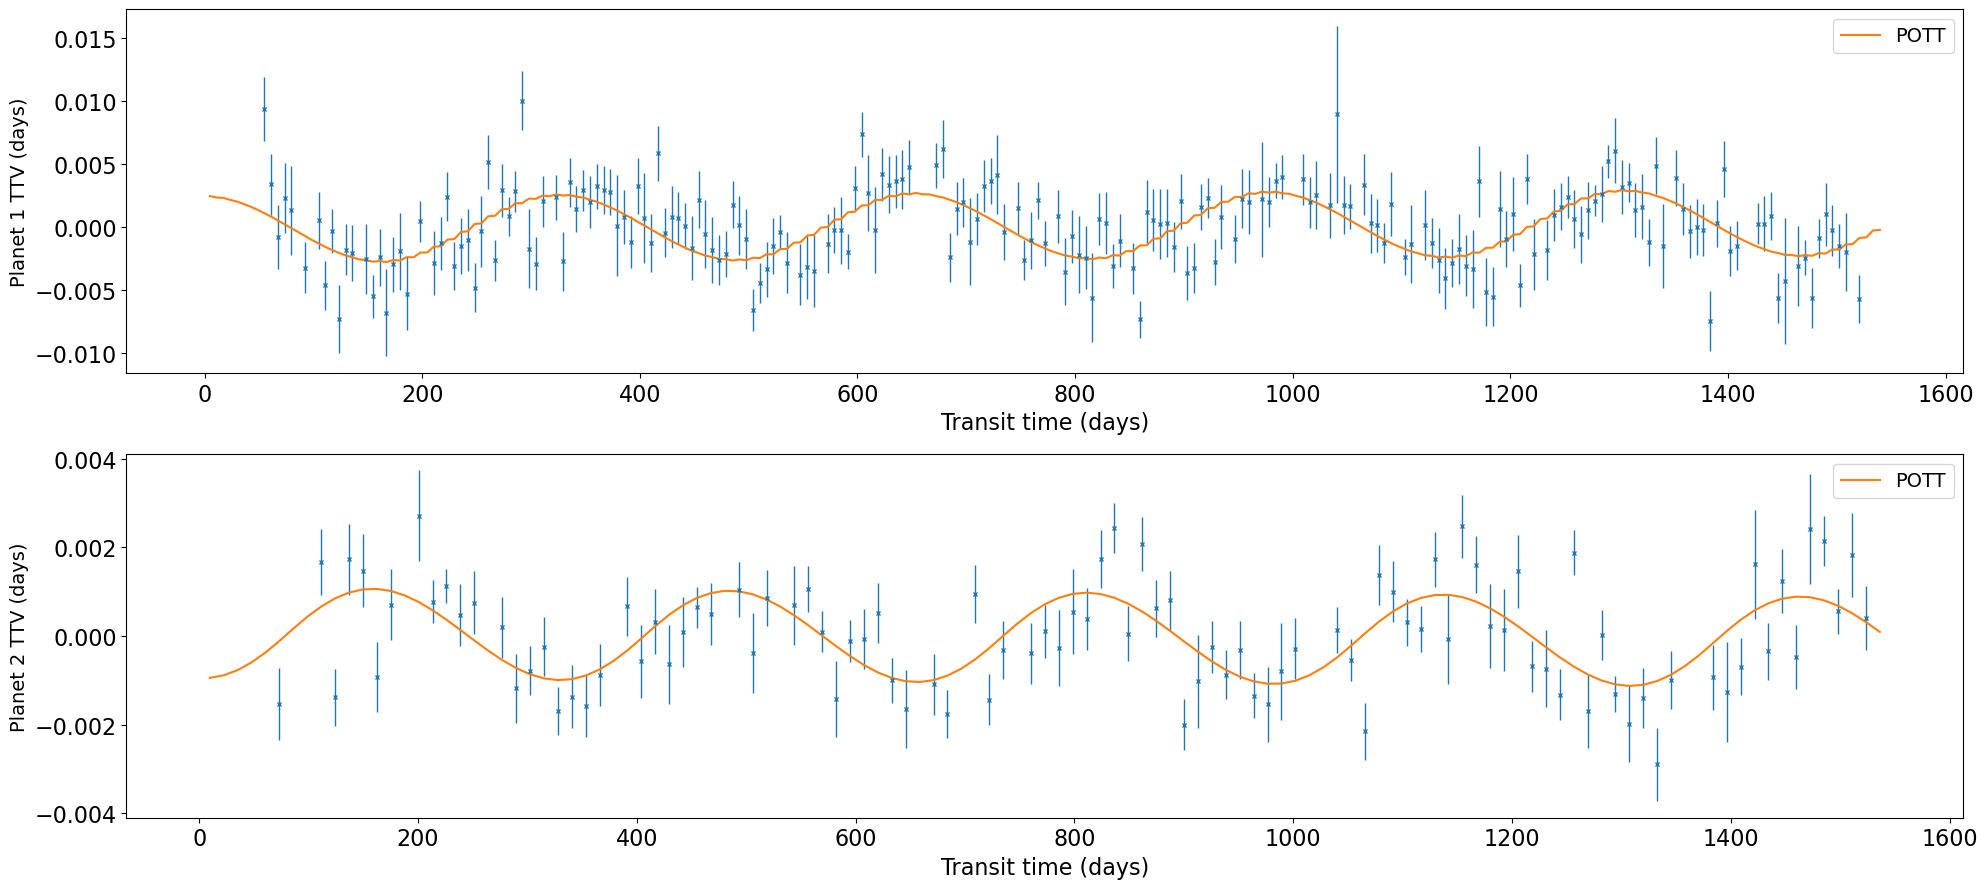

In [9]:
fig, ax = subplots(2, 1, figsize=(20,9), tight_layout=true)

for i in 1:2
    cal_transits = estimate_period(tt_data, i, [10., 0.])[2];
    obs_transits = tt_data[tt_data[:,1] .== convert(Float64,i),3];
    
    ax[i].errorbar(obs_transits, obs_transits .- cal_transits, yerr = tt_data[tt_data[:,1] .== convert(Float64,i),4], 
        fmt="x", linestyle="", markersize=3, linewidth=1)
    
    # cal_transits_coeffs = estimate_period(tt_clean, i, [10., 0.])[1];
    # cal_transits = linear.(0:(sum(tt_clean[:,1] .== convert(Float64, i))-1), cal_transits_coeffs...)
    # obs_transits = tt_clean[tt_clean[:,1] .== convert(Float64,i),3];

    # ax[i].plot(obs_transits, obs_transits .- cal_transits, label="Truth")

    cal_transits_coeffs = estimate_period(tt_model, i, [10., 0.])[1];
    cal_transits = linear.(0:(sum(tt_model[:,1] .== convert(Float64, i))-1), cal_transits_coeffs...)
    obs_transits = tt_model[tt_model[:,1] .== convert(Float64,i),3];

    ax[i].plot(obs_transits, obs_transits .- cal_transits, label="POTT")

    # cal_transits_coeffs = estimate_period(tt_model_tt, i, [10., 0.])[1];
    # cal_transits = linear.(0:(sum(tt_model_tt[:,1] .== convert(Float64, i))-1), cal_transits_coeffs...)
    # obs_transits = tt_model_tt[tt_model_tt[:,1] .== convert(Float64,i),3];

    # ax[i].plot(obs_transits, obs_transits .- cal_transits, label="TT-only")

    ax[i].set_ylabel("Planet $i TTV (days)", fontsize=14)
    ax[i].set_xlabel("Transit time (days)", fontsize=16)

    ax[i].tick_params(labelsize=16)

    ax[i].legend(fontsize=14)

    # ax[i].set_xlim(5500, 6000)
end

In [10]:
# Long-term stability plot

function figure_A7_plot(state, ic, intstep, timestep, timemax)
    arb_state = deepcopy(state)
    
    @show h = intstep
    @show n_steps = convert(Int, timemax ÷ timestep)
    
    e_1 = Vector{Any}(undef, n_steps)
    e_2 = Vector{Any}(undef, n_steps)
    
    lambda_1 = Vector{Any}(undef, n_steps)
    lambda_2 = Vector{Any}(undef, n_steps)
    
    P1 = Vector{Any}(undef, n_steps)
    P2 = Vector{Any}(undef, n_steps)

    ω1 = Vector{Any}(undef, n_steps)
    ω2 = Vector{Any}(undef, n_steps)
    
    times = Vector{Any}(undef, n_steps)
    
    for i = 1:n_steps
        Integrator(ahl21!,h,timestep)(arb_state)
        
        times[i] = arb_state.t[1]
    
        e_1[i] = get_Jacobi_orbital_elements(arb_state, ic)[2].e
        e_2[i] = get_Jacobi_orbital_elements(arb_state, ic)[3].e
    
        lambda_1[i] = get_Jacobi_anomalies(arb_state, ic)[1][1] + get_Jacobi_orbital_elements(arb_state, ic)[2].ω
        lambda_2[i] = get_Jacobi_anomalies(arb_state, ic)[2][1] + get_Jacobi_orbital_elements(arb_state, ic)[3].ω
    
        P1[i] = get_Jacobi_orbital_elements(arb_state, ic)[2].P
        P2[i] = get_Jacobi_orbital_elements(arb_state, ic)[3].P

        ω1[i] = get_Jacobi_orbital_elements(arb_state, ic)[2].ω
        ω2[i] = get_Jacobi_orbital_elements(arb_state, ic)[3].ω
    end

    return times, e_1, e_2, lambda_1, lambda_2, P1, P2, ω1, ω2
end

function diff_angle_jac(init_state, final_state, ic)
    # shifting_angle = mean([get_Jacobi_orbital_elements(final_state, ic)[i].ω - get_Jacobi_orbital_elements(init_state, ic)[i].ω for i in 2:3])
    shifting_angle = get_Jacobi_orbital_elements(final_state, ic)[2].ω - get_Jacobi_orbital_elements(init_state, ic)[2].ω
    shifting_angle = rem2pi(shifting_angle, RoundNearest)
    return shifting_angle
end

diff_angle_jac (generic function with 1 method)

h = intstep = 0.06239141712030713
n_steps = convert(Int, timemax ÷ timestep) = 320


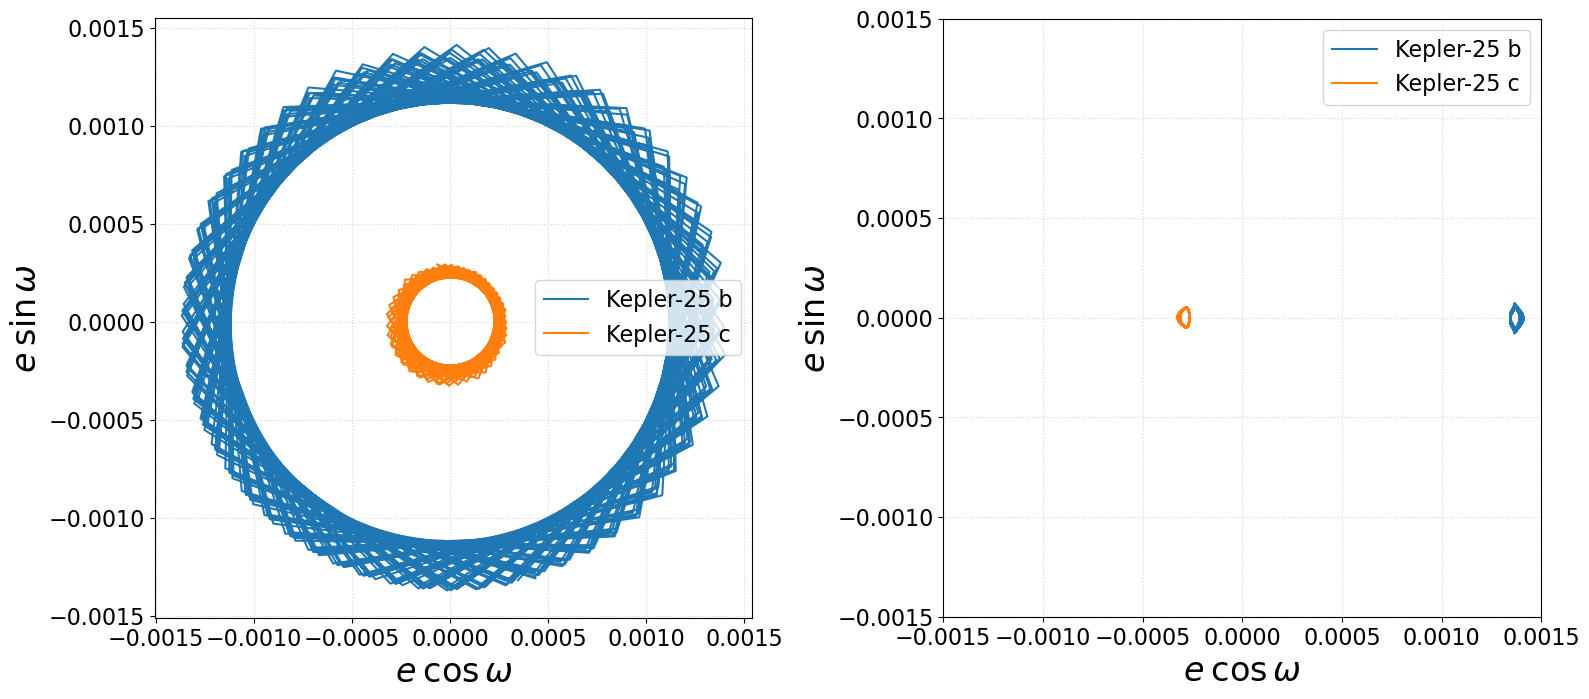

(-0.0015, 0.0015)

In [11]:
# orbit_1 = Orbit(2, OptimParameters(2, current_optvec .* scaler), orbparams)
optparams_1 = OptimParameters(2, fitres.param .* scaler)
orbit_1 = Orbit(2, optparams_1, orbparams)

t_sys = (fitres.param .* scaler)[end]

times, e_1, e_2, lambda_1, lambda_2, P1, P2, ω1, ω2 = 
    # figure_A7_plot(orbit_1.s, orbit_1.ic, optparams_1.inner_period / 100, optparams_1.tsys/30.0, 10*365.242*1e3);
    figure_A7_plot(orbit_1.s, orbit_1.ic, optparams_1.inner_period / 100, 10 * optparams_1.inner_period, 20000.);

shifted_omega = diff_angle_jac(orbit_1.s, orbit_1.state_final, orbit_1.ic)

ω1_rot = ω1 .- (shifted_omega / t_sys) .* times
ω2_rot = ω2 .- (shifted_omega / t_sys) .* times

fig, ax = subplots(1, 2, figsize=(16,8), tight_layout=true)

# ax[1].set_title("Inertial Frame", fontsize=26)
ax[1].plot(e_1.*cos.(ω1), e_1.*sin.(ω1),label="Kepler-25 b")
ax[1].plot(e_2.*cos.(ω2), e_2.*sin.(ω2),label="Kepler-25 c")

# ax[2].set_title("Rotating Frame", fontsize=26)
ax[2].plot(e_1.*cos.(ω1_rot), e_1.*sin.(ω1_rot),label="Kepler-25 b")
ax[2].plot(e_2.*cos.(ω2_rot), e_2.*sin.(ω2_rot),label="Kepler-25 c")

for i in 1:2
    ax[i].set_xlabel("\$e\\:\\cos{\\omega}\$", fontsize=24)
    ax[i].set_ylabel("\$e\\:\\sin{\\omega}\$", fontsize=24)
    ax[i].grid(linestyle=":", alpha=0.5)
    ax[i].set_aspect("equal")
    ax[i].legend(fontsize=16)

    ax[i].tick_params("both", labelsize=16)
end

ax[2].set_ylim(-0.0015, 0.0015)
ax[2].set_xlim(-0.0015, 0.0015)

# savefig("figures/gm20_10aka_vector_dual.pdf")

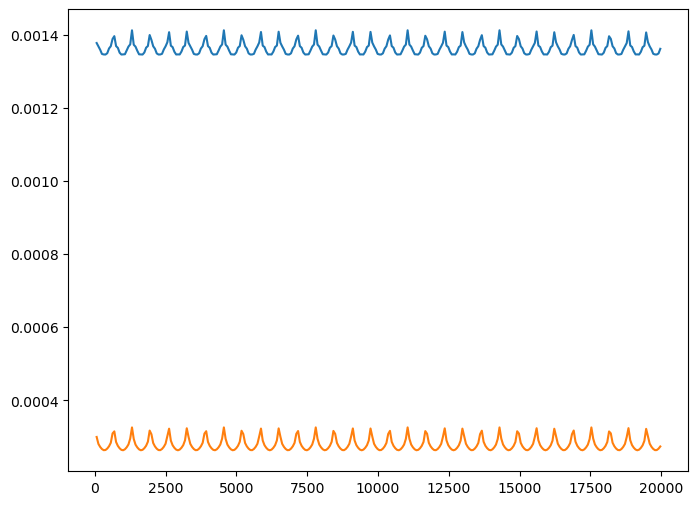

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x15625d810>

In [12]:
fig, ax = subplots(figsize=(8,6))

ax.plot(times, e_1)
ax.plot(times, e_2)

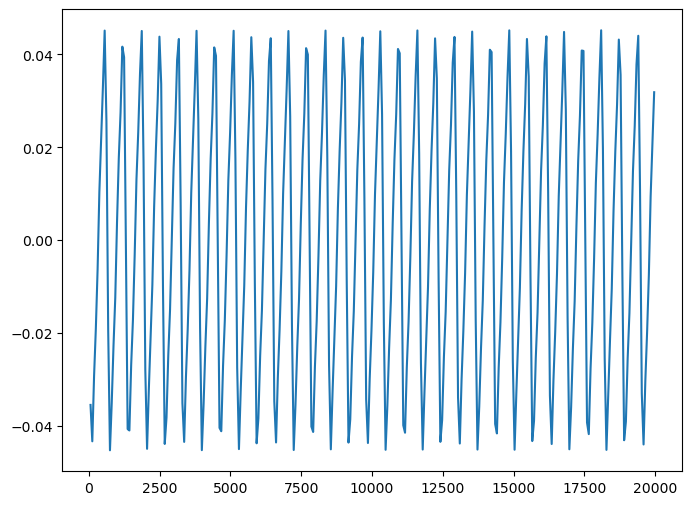

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x1562c8e10>

In [13]:
fig, ax = subplots(figsize=(8,6))

# ax.plot(times, lambda_1)
# ax.plot(times, lambda_2)

ax.plot(times, rem2pi.(lambda_1 - 2lambda_2 + ω1, RoundNearest))

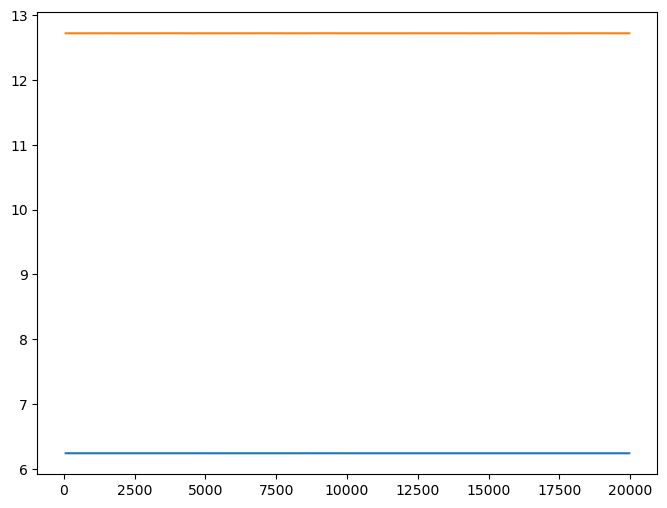

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x156327c50>

In [14]:
fig, ax = subplots(figsize=(8,6))

ax.plot(times, P1)
ax.plot(times, P2)

In [15]:
get_orbital_elements(orbit_1.s, orbit_1.ic)[3].P

12.722504987317713

In [16]:
ME = 5.972e24 # Earth mass (kg)
MSUN = 1.99e30 # Sun mass (kg)
MSTAR = 1.19 # Reported stellar mass in MG17

1.19

In [17]:
# Mass ratios
optparams_1.masses

2-element Vector{Float64}:
 2.731691662210383e-5
 3.6696072322970227e-5

In [18]:
# In earth masses!
optparams_1.masses .* (MSTAR * MSUN) ./ ME

2-element Vector{Float64}:
 10.83208142210383
 14.551233902884425